In [23]:
import os, sys

# Repository information
REPO_NAME = "RecSys-Challenge-2025"
REPO_URL  = f"github.com/Lv1g1/{REPO_NAME}.git"

# Detect environment
IS_COLAB = 'content' in os.getcwd()
IS_KAGGLE = 'kaggle' in os.getcwd()
IS_LOCAL = not (IS_COLAB or IS_KAGGLE)

if IS_COLAB:
    WORKING_DIR = "/content"

    # Mount Google Drive
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)

    # Get GitHub token via input
    def get_token():
        from getpass import getpass
        return getpass("GitHub Token: ")

elif IS_KAGGLE:
    WORKING_DIR = "/kaggle/working"

    # Get GitHub token from Kaggle secrets
    def get_token():
        from kaggle_secrets import UserSecretsClient
        return UserSecretsClient().get_secret("Token")

# If local environment assume inside the repo
LOCAL_REPO_PATH = os.getcwd() if IS_LOCAL else os.path.join(WORKING_DIR, REPO_NAME)

# Clone the repository if it doesn't exist
if not os.path.exists(LOCAL_REPO_PATH):
    os.chdir(WORKING_DIR)
    token = get_token()

    !git clone https://{token}@{REPO_URL}
else:
    print("Repo already exists — pulling latest changes")
    os.chdir(LOCAL_REPO_PATH)
    !git pull
    os.chdir(WORKING_DIR)

# Add to Python PATH
if LOCAL_REPO_PATH not in sys.path:
    sys.path.append(LOCAL_REPO_PATH)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Repo already exists — pulling latest changes
Already up to date.


In [24]:
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.sparse as sps

from Challenge import paths
importlib.reload(paths)

Running on colab — storage at: /content/drive/MyDrive/RecSys


<module 'Challenge.paths' from '/content/RecSys-Challenge-2025/Challenge/paths.py'>

In [25]:
# Import data
URM_all_dataframe = pd.read_csv(filepath_or_buffer=paths.CHALLENGE_DATASET,
                                dtype={0:int, 1:int})

print ("The number of interactions is {}".format(len(URM_all_dataframe)))
URM_all_dataframe.head(n=10)

The number of interactions is 3043058


,row,col
0,0,44
1,0,227
2,0,236
3,0,247
4,0,325
5,0,464
6,0,504
7,0,640
8,0,656
9,0,841


In [26]:
# rename columns
URM_all_dataframe.columns = ["UserID", "ItemID"]

# Extract the list of unique user id and item id
userID_unique = URM_all_dataframe["UserID"].unique()
itemID_unique = URM_all_dataframe["ItemID"].unique()

n_users = len(userID_unique)
n_items = len(itemID_unique)
n_interactions = len(URM_all_dataframe)

print ("Number of items\t {}, Number of users\t {}".format(n_items, n_users))
print ("Max ID items\t {}, Max Id users\t {}\n".format(max(itemID_unique), max(userID_unique)))

Number of items	 6969, Number of users	 27095
Max ID items	 6968, Max Id users	 27094



In [27]:
# Ids required for the submission
user_ids_test = pd.read_csv(paths.CHALLENGE_USER_IDS_TEST)
print("Number of users in the test set: {}".format(len(user_ids_test)))
user_ids_test.head(n=10)

Number of users in the test set: 27095


,user_id
0,0
1,1
2,2
3,3
4,4
5,5
6,6
7,7
8,8
9,9


In [28]:
print ("Number of items\t {}, Number of users\t {}".format(n_items, n_users))
print ("Max ID items\t {}, Max Id users\t {}\n".format(max(itemID_unique), max(userID_unique)))
print ("Average interactions per user {:.2f}".format(n_interactions/n_users))
print ("Average interactions per item {:.2f}".format(n_interactions/n_items))
print ("Total interactions {}\n".format(n_interactions))

print ("Sparsity {:.2f} %".format((1-float(n_interactions)/(n_items*n_users))*100))

Number of items	 6969, Number of users	 27095
Max ID items	 6968, Max Id users	 27094

Average interactions per user 112.31
Average interactions per item 436.66
Total interactions 3043058

Sparsity 98.39 %


In [29]:
# Create the User-Rating-Matrix in sparse format
URM_all = sps.coo_matrix((np.ones(n_interactions),
                          (URM_all_dataframe["UserID"].values,
                           URM_all_dataframe["ItemID"].values)))

URM_all = URM_all.tocsr()

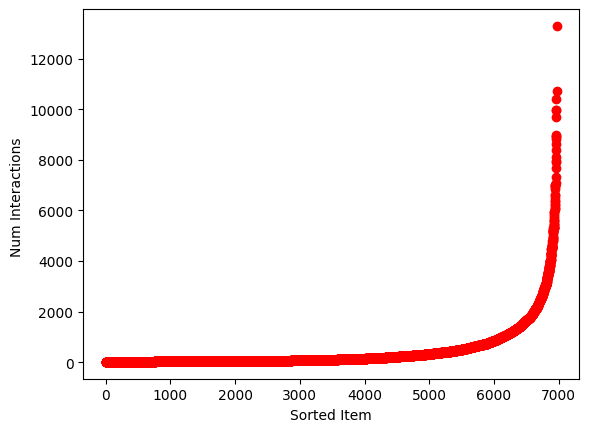

In [30]:
# Plot item popularity
item_popularity = np.ediff1d(URM_all.tocsc().indptr)
item_popularity = np.sort(item_popularity)

plt.plot(item_popularity, 'ro')
plt.ylabel('Num Interactions ')
plt.xlabel('Sorted Item')
plt.show()

In [31]:
ten_percent = int(n_items/10)

print("Average per-item interactions over the whole dataset {:.2f}".
      format(item_popularity.mean()))

print("Average per-item interactions for the top 10% popular items {:.2f}".
      format(item_popularity[-ten_percent:].mean()))

print("Average per-item interactions for the least 10% popular items {:.2f}".
      format(item_popularity[:ten_percent].mean()))

print("Average per-item interactions for the median 10% popular items {:.2f}".
      format(item_popularity[int(n_items*0.45):int(n_items*0.55)].mean()))

# Check for items with no interactions
print("Number of items with zero interactions {}".
      format(np.sum(item_popularity==0)))

Average per-item interactions over the whole dataset 436.66
Average per-item interactions for the top 10% popular items 2587.24
Average per-item interactions for the least 10% popular items 21.62
Average per-item interactions for the median 10% popular items 98.90
Number of items with zero interactions 0


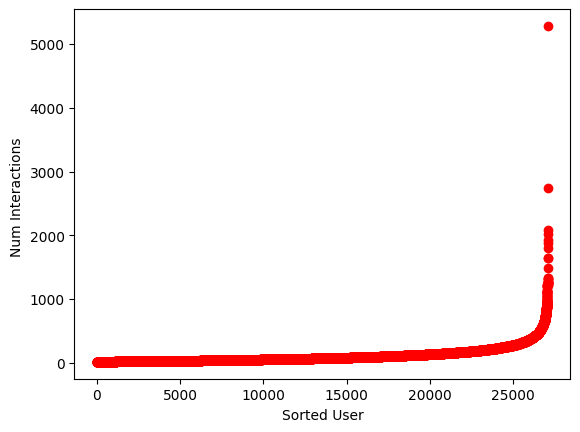

In [32]:
# Plot user activity
user_activity = np.ediff1d(URM_all.tocsr().indptr)
user_activity = np.sort(user_activity)

plt.plot(user_activity, 'ro')
plt.ylabel('Num Interactions ')
plt.xlabel('Sorted User')
plt.show()

In [33]:
# Save the preprocessed URM
sps.save_npz(paths.URM_PATH, URM_all)

In [34]:
from Data_manager.split_functions.split_train_validation_random_holdout import split_train_in_two_percentage_global_sample

# Split the URM into training and validation sets
URM_train, URM_validation = split_train_in_two_percentage_global_sample(URM_all, train_percentage = 0.80)

In [ ]:
# Check splits
print("URM_all:", URM_all.shape)
print("URM_train:", URM_train.shape)
print("URM_validation:", URM_validation.shape)
print()
print("URM_all:", len(URM_all.nonzero()[0]))
print("URM_train:", len(URM_train.nonzero()[0]))
print("URM_validation:", len(URM_validation.nonzero()[0]))

URM_all: (27095, 6969)
URM_train: (27095, 6969)
URM_validation: (27095, 6969)

URM_all: 3043058
URM_train: 2434446
URM_validation: 608612


In [36]:
# Save the training and validation URMs
sps.save_npz(paths.URM_TRAIN, URM_train)
sps.save_npz(paths.URM_VALIDATION, URM_validation)